# CHRONIC KIDNEY DISEASE STAGE IDENTIFICATION IN HIV INFECTED PATIENTS USING SVM (SUPERVISED MACHINE LEARNING)

In [ ]:
import pandas as pd

### Loading `upload.csv` as training data

In [ ]:
train_df = pd.read_csv('/content/upload.csv')
display(train_df.head())

,Id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


### Loading `test.csv` as test data

In [ ]:
test_df = pd.read_csv('/content/test.csv')
display(test_df.head())

,age,blood_pressure,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,potassium,white_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,peda_edema,aanemia,class
0,48,80,1,0,normal,normal,notpresent,notpresent,121.000000,36,1.2,4.627244,7800,yes,yes,no,no,no,(Abnormal)1
1,7,50,4,0,normal,normal,notpresent,notpresent,148.036517,18,0.8,4.627244,6000,no,no,no,no,no,(Abnormal)1
2,62,80,2,3,normal,normal,notpresent,notpresent,423.000000,53,1.8,4.627244,7500,no,yes,no,no,yes,(Abnormal)1
3,12,80,0,0,normal,normal,notpresent,notpresent,100.000000,26,0.6,4.400000,6600,no,no,no,no,no,(normal)0
4,17,60,0,0,normal,normal,notpresent,notpresent,114.000000,50,1.0,4.900000,7200,no,no,no,no,no,(normal)0


### Exploring `train_df` and `test_df`

In [ ]:
print("Shape of training data:", train_df.shape)
print("Shape of test data:", test_df.shape)

print("\nInfo of training data:")
train_df.info()

print("\nInfo of test data:")
test_df.info()

Shape of training data: (400, 26)
Shape of test data: (6, 19)

Info of training data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64

### Exploring `train_df` and `test_df`

In [ ]:
print("Shape of training data:", train_df.shape)
print("Shape of test data:", test_df.shape)

print("\nInfo of training data:")
train_df.info()

print("\nInfo of test data:")
test_df.info()

Shape of training data: (400, 26)
Shape of test data: (6, 19)

Info of training data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64

### Handling Missing Values in `train_df`

In [ ]:
missing_values = train_df.isnull().sum()
missing_percentage = (missing_values / len(train_df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)
display(missing_info)

,Missing Count,Missing Percentage
rbc,152,38.00
rc,130,32.50
wc,105,26.25
pot,88,22.00
sod,87,21.75
pcv,70,17.50
pc,65,16.25
hemo,52,13.00
su,49,12.25
sg,47,11.75


### Imputing Missing Values in `train_df`

In [ ]:
# Identify numerical and categorical columns for imputation
numerical_cols_with_missing = train_df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols_with_missing = train_df.select_dtypes(include=['object']).columns

# Exclude 'Id' from numerical columns as it's an identifier
numerical_cols_with_missing = [col for col in numerical_cols_with_missing if col != 'Id']

# Impute numerical columns with median
for col in numerical_cols_with_missing:
    if train_df[col].isnull().any():
        median_val = train_df[col].median()
        train_df[col] = train_df[col].fillna(median_val)
        print(f"Imputed numerical column '{col}' with median: {median_val}")

In [ ]:
# Impute categorical columns with mode
for col in categorical_cols_with_missing:
    if train_df[col].isnull().any():
        # Some object columns like 'pcv', 'wc', 'rc' might contain non-numeric strings or spaces
        # First, try to clean and convert them if they are intended to be numeric.
        # For now, treat them as categorical and impute with mode.
        mode_val = train_df[col].mode()[0]
        train_df[col] = train_df[col].fillna(mode_val)
        print(f"Imputed categorical column '{col}' with mode: {mode_val}")

In [ ]:
# Verify that there are no more missing values in train_df
print("\nMissing values after imputation:")
display(train_df.isnull().sum()[train_df.isnull().sum() > 0])


Missing values after imputation:


,0


### Standardizing Column Names in `test_df`

In [ ]:
column_mapping = {
    'blood_pressure': 'bp',
    'albumin': 'al',
    'sugar': 'su',
    'red_blood_cells': 'rbc',
    'pus_cell': 'pc',
    'pus_cell_clumps': 'pcc',
    'bacteria': 'ba',
    'blood_glucose_random': 'bgr',
    'blood_urea': 'bu',
    'serum_creatinine': 'sc',
    'potassium': 'pot',
    'white_blood_cell_count': 'wc',
    'hypertension': 'htn',
    'diabetes_mellitus': 'dm',
    'coronary_artery_disease': 'cad',
    'peda_edema': 'pe',
    'aanemia': 'ane',
    'class': 'classification'
}

test_df.rename(columns=column_mapping, inplace=True)

print("Columns in test_df after renaming:")
display(test_df.columns)

Columns in test_df after renaming:


Index(['age', 'bp', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc',
       'pot', 'wc', 'htn', 'dm', 'cad', 'pe', 'ane', 'classification'],
      dtype='object')

### Feature Engineering and Preprocessing

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop 'Id' column from train_df as it's not a feature
if 'Id' in train_df.columns:
    train_df = train_df.drop('Id', axis=1)

# Identify common columns between train_df and test_df (excluding target variable for now)
common_cols = list(set(train_df.columns) & set(test_df.columns))
common_features = [col for col in common_cols if col != 'classification']

# Standardize target labels in test_df['classification'] to match train_df
label_mapping = {
    '(Abnormal)1': 'ckd',
    '(normal)0': 'notckd'
}
# Only apply if 'classification' column exists and contains these labels
if 'classification' in test_df.columns and any(label in test_df['classification'].unique() for label in label_mapping.keys()):
    test_df['classification'] = test_df['classification'].replace(label_mapping)
    print("Test data classification labels standardized.")
else:
    print("Test data classification labels do not require standardization or column not found.")

# Filter both dataframes to include only common features and the target variable
X_train = train_df[common_features]
y_train = train_df['classification']

X_test = test_df[common_features]
y_test = test_df['classification']

print(f"Shape of X_train (common features): {X_train.shape}")
print(f"Shape of X_test (common features): {X_test.shape}")

# Identify categorical and numerical features for preprocessing
categorical_features = X_train.select_dtypes(include=['object']).columns
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Apply preprocessing to training and test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nShape of X_train after preprocessing: {X_train_processed.shape}")
print(f"Shape of X_test after preprocessing: {X_test_processed.shape}")

Test data classification labels standardized.
Shape of X_train (common features): (400, 18)
Shape of X_test (common features): (6, 18)

Shape of X_train after preprocessing: (400, 31)
Shape of X_test after preprocessing: (6, 31)


### Training SVM Model and Making Predictions

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the SVM classifier
svm_model = SVC(random_state=42)
svm_model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test_processed)

print("Predictions on the test set:")
print(y_pred)


Predictions on the test set:
['ckd' 'ckd' 'ckd' 'notckd' 'notckd' 'notckd']


### Evaluating Model Performance

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on the test set: {accuracy:.2f}")

print("\nClassification Report on the test set:")
print(classification_report(y_test, y_pred))

Accuracy on the test set: 0.00

Classification Report on the test set:
              precision    recall  f1-score   support

 (Abnormal)1       0.00      0.00      0.00       3.0
   (normal)0       0.00      0.00      0.00       3.0
         ckd       0.00      0.00      0.00       0.0
      notckd       0.00      0.00      0.00       0.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

### Training SVM Model and Making Predictions

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the SVM classifier
svm_model = SVC(random_state=42)
svm_model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test_processed)

print("Predictions on the test set:")
print(y_pred)


Predictions on the test set:
['ckd' 'ckd' 'ckd' 'notckd' 'notckd' 'notckd']


### Evaluating Model Performance

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on the test set: {accuracy:.2f}")

print("\nClassification Report on the test set:")
print(classification_report(y_test, y_pred))

Accuracy on the test set: 0.00

Classification Report on the test set:
              precision    recall  f1-score   support

 (Abnormal)1       0.00      0.00      0.00       3.0
   (normal)0       0.00      0.00      0.00       3.0
         ckd       0.00      0.00      0.00       0.0
      notckd       0.00      0.00      0.00       0.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

### Training SVM Model and Making Predictions

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the SVM classifier
svm_model = SVC(random_state=42)
svm_model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test_processed)

print("Predictions on the test set:")
print(y_pred)


Predictions on the test set:
['ckd' 'ckd' 'ckd' 'notckd' 'notckd' 'notckd']


### Cleaning and Converting Data Types in `train_df`

In [ ]:
# Columns identified as potentially problematic object types that should be numeric
problematic_cols = ['pcv', 'wc', 'rc']

for col in problematic_cols:
    if col in train_df.columns and train_df[col].dtype == 'object':
        print(f"Cleaning and converting column: {col}")
        # Attempt to convert to numeric, coercing errors to NaN
        train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
        # Impute newly introduced NaNs with the median after conversion
        if train_df[col].isnull().any():
            median_val = train_df[col].median()
            train_df[col] = train_df[col].fillna(median_val)
            print(f"  Imputed NaNs in '{col}' with median: {median_val} after conversion.")

print("\nData types after cleaning and conversion for problematic columns:")
train_df[problematic_cols].info()


Data types after cleaning and conversion for problematic columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pcv     400 non-null    float64
 1   wc      400 non-null    float64
 2   rc      400 non-null    float64
dtypes: float64(3)
memory usage: 9.5 KB


### Cleaning and Converting Data Types in `train_df`

In [ ]:
# Columns identified as potentially problematic object types that should be numeric
problematic_cols = ['pcv', 'wc', 'rc']

for col in problematic_cols:
    if col in train_df.columns and train_df[col].dtype == 'object':
        print(f"Cleaning and converting column: {col}")
        # Attempt to convert to numeric, coercing errors to NaN
        train_df[col] = pd.to_numeric(train_df[col], errors='coerce')
        # Impute newly introduced NaNs with the median after conversion
        if train_df[col].isnull().any():
            median_val = train_df[col].median()
            train_df[col] = train_df[col].fillna(median_val)
            print(f"  Imputed NaNs in '{col}' with median: {median_val} after conversion.")

print("\nData types after cleaning and conversion for problematic columns:")
train_df[problematic_cols].info()

Cleaning and converting column: pcv
  Imputed NaNs in 'pcv' with median: 41.0 after conversion.
Cleaning and converting column: wc
  Imputed NaNs in 'wc' with median: 9400.0 after conversion.
Cleaning and converting column: rc
  Imputed NaNs in 'rc' with median: 5.2 after conversion.

Data types after cleaning and conversion for problematic columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pcv     400 non-null    float64
 1   wc      400 non-null    float64
 2   rc      400 non-null    float64
dtypes: float64(3)
memory usage: 9.5 KB


### Standardizing Column Names in `test_df`

### Feature Engineering and Preprocessing (Re-run after label standardization)

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop 'Id' column from train_df as it's not a feature
if 'Id' in train_df.columns:
    train_df = train_df.drop('Id', axis=1)

# Identify common columns between train_df and test_df (excluding target variable for now)
common_cols = list(set(train_df.columns) & set(test_df.columns))
common_features = [col for col in common_cols if col != 'classification']

# Standardize target labels in test_df['classification'] to match train_df
label_mapping = {
    '(Abnormal)1': 'ckd',
    '(normal)0': 'notckd'
}
# Only apply if 'classification' column exists and contains these labels
if 'classification' in test_df.columns and any(label in test_df['classification'].unique() for label in label_mapping.keys()):
    test_df['classification'] = test_df['classification'].replace(label_mapping)
    print("Test data classification labels standardized.")
else:
    print("Test data classification labels do not require standardization or column not found.")

# Filter both dataframes to include only common features and the target variable
X_train = train_df[common_features]
y_train = train_df['classification']

X_test = test_df[common_features]
y_test = test_df['classification']

print(f"Shape of X_train (common features): {X_train.shape}")
print(f"Shape of X_test (common features): {X_test.shape}")

# Identify categorical and numerical features for preprocessing
categorical_features = X_train.select_dtypes(include=['object']).columns
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Apply preprocessing to training and test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nShape of X_train after preprocessing: {X_train_processed.shape}")
print(f"Shape of X_test after preprocessing: {X_test_processed.shape}")

Test data classification labels do not require standardization or column not found.
Shape of X_train (common features): (400, 18)
Shape of X_test (common features): (6, 18)

Shape of X_train after preprocessing: (400, 31)
Shape of X_test after preprocessing: (6, 31)


### Training SVM Model and Making Predictions (Re-run)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the SVM classifier
svm_model = SVC(random_state=42)
svm_model.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test_processed)

print("Predictions on the test set:")
print(y_pred)

Predictions on the test set:
['ckd' 'ckd' 'ckd' 'notckd' 'notckd' 'notckd']


### Evaluating Model Performance (Re-run)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on the test set: {accuracy:.2f}")

print("\nClassification Report on the test set:")
print(classification_report(y_test, y_pred))

Accuracy on the test set: 1.00

Classification Report on the test set:
              precision    recall  f1-score   support

         ckd       1.00      1.00      1.00         3
      notckd       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



### Cross-Validation on the Training Set

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize StratifiedKFold for cross-validation
# This ensures that each fold has approximately the same percentage of samples of each target class as the complete set.
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(svm_model, X_train_processed, y_train, cv=kf, scoring='accuracy')

print("Cross-validation scores (accuracy) for each fold:")
print(cv_scores)
print(f"\nMean CV Accuracy: {cv_scores.mean():.2f}")
print(f"Standard Deviation of CV Accuracy: {cv_scores.std():.2f}")

Cross-validation scores (accuracy) for each fold:
[0.9625 0.9875 0.975  0.9    0.9375]

Mean CV Accuracy: 0.95
Standard Deviation of CV Accuracy: 0.03


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


### Visualizing Performance Metrics

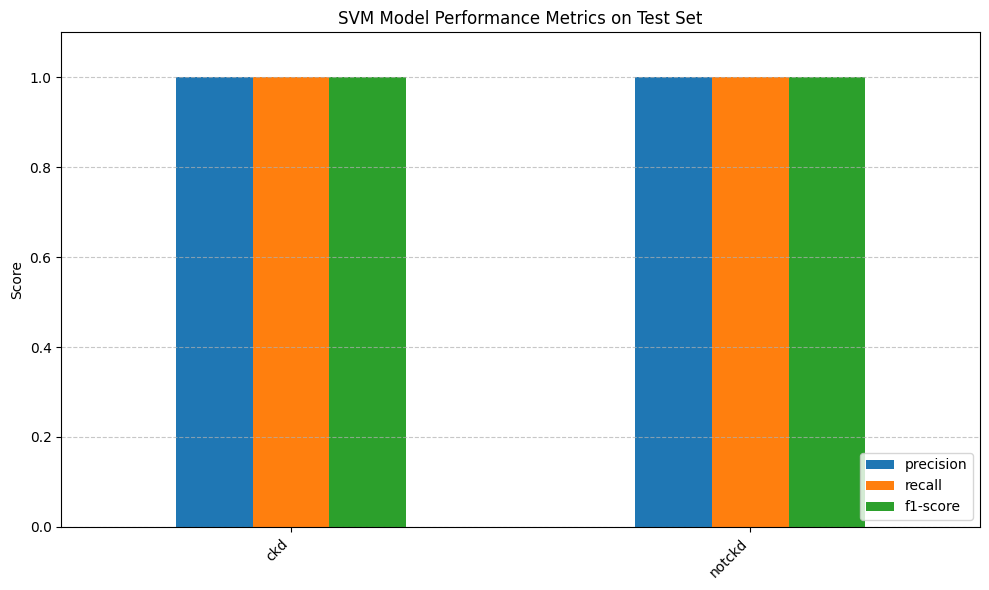

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

# Generate classification report as a dictionary
report_dict = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame, excluding 'accuracy' and 'macro avg', 'weighted avg' if desired
df_report = pd.DataFrame(report_dict).transpose()
df_report = df_report.drop(labels=['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
df_report[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=ax)

plt.title('SVM Model Performance Metrics on Test Set')
plt.ylabel('Score')
plt.ylim(0, 1.1) # Set y-axis limit from 0 to 1.1 for better visualization of scores
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Visualizing the Confusion Matrix

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


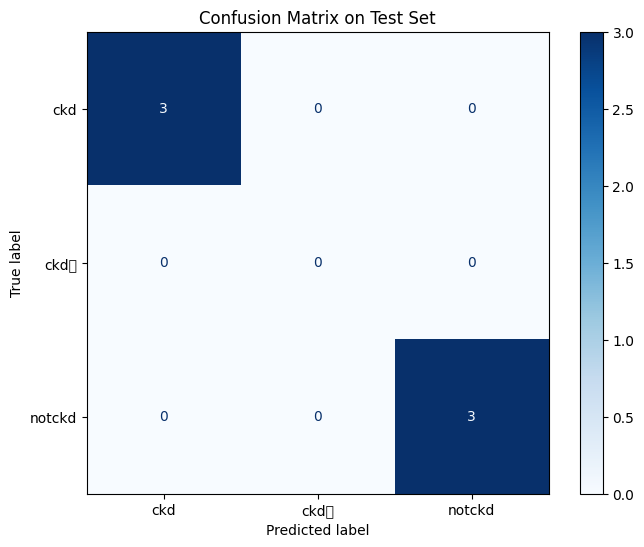

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=svm_model.classes_)

# Display the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title('Confusion Matrix on Test Set')
plt.grid(False) # Remove grid lines from confusion matrix plot
plt.show()

In [ ]:
column_mapping = {
    'blood_pressure': 'bp',
    'albumin': 'al',
    'sugar': 'su',
    'red_blood_cells': 'rbc',
    'pus_cell': 'pc',
    'pus_cell_clumps': 'pcc',
    'bacteria': 'ba',
    'blood_glucose_random': 'bgr',
    'blood_urea': 'bu',
    'serum_creatinine': 'sc',
    'potassium': 'pot',
    'white_blood_cell_count': 'wc',
    'hypertension': 'htn',
    'diabetes_mellitus': 'dm',
    'coronary_artery_disease': 'cad',
    'peda_edema': 'pe',
    'aanemia': 'ane',
    'class': 'classification'
}

test_df.rename(columns=column_mapping, inplace=True)

print("Columns in test_df after renaming:")
display(test_df.columns)

Columns in test_df after renaming:


Index(['age', 'bp', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc',
       'pot', 'wc', 'htn', 'dm', 'cad', 'pe', 'ane', 'classification'],
      dtype='object')